# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_predict, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, QuantileTransformer, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from pygam import LinearGAM, s
from scipy.stats import randint, uniform
import scipy.sparse
import warnings
warnings.filterwarnings("ignore")

# 2. Load and Preprocess Data

In [2]:
df = pd.read_csv("data/movie_data_encoded.csv")

def handle_outliers(df, columns, method='cap'):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.05)
        Q3 = df_clean[col].quantile(0.95)
        IQR = Q3 - Q1
        lower_bound = Q1 - 2 * IQR
        upper_bound = Q3 + 2 * IQR
        if method == 'cap':
            df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)
    return df_clean

def plot_residual_diagnostics(y_true, y_pred):
    residuals = y_true - y_pred
    standardized_residuals = (residuals - np.mean(residuals)) / np.std(residuals)
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    axs[0, 0].scatter(y_pred, residuals, alpha=0.6)
    axs[0, 0].axhline(0, color='red', linestyle='--')
    axs[0, 0].set_title('Residuals vs Fitted')
    axs[0, 0].set_xlabel('Fitted Values')
    axs[0, 0].set_ylabel('Residuals')
    stats.probplot(residuals, dist="norm", plot=axs[0, 1])
    axs[0, 1].set_title('Normal Q-Q Plot')
    sns.histplot(residuals, bins=30, kde=True, ax=axs[1, 0])
    axs[1, 0].set_title('Histogram of Residuals')
    axs[1, 1].plot(residuals, marker='o', linestyle='', alpha=0.6)
    axs[1, 1].axhline(0, color='red', linestyle='--')
    axs[1, 1].set_title('Residuals vs Observation Order')
    axs[1, 1].set_xlabel('Observation Order')
    axs[1, 1].set_ylabel('Residual')
    plt.tight_layout()
    plt.show()

def error_analysis(y_true, y_pred, X_data):
    residuals = y_true - y_pred
    error_df = X_data.assign(
        true_revenue=y_true / 1e6,
        pred_revenue=y_pred / 1e6,
        residual=residuals / 1e6,
        pct_error=residuals / y_true
    )
    print("Top 5 Underestimations:")
    display(error_df.nlargest(5, 'residual'))
    print("\nTop 5 Overestimations:")
    display(error_df.nsmallest(5, 'residual'))
    return error_df

def check_revenue_distribution(series):
    plt.figure(figsize=(8,5))
    sns.histplot(series, bins=50, kde=True)
    plt.title("Revenue Distribution")
    plt.show()

# Initial data cleaning
df_clean = df[(df['trailer_views'] >= 0) & (df['trailer_likes'] >= 0)].copy()
df_clean = df_clean.dropna(subset=['release_date', 'budget', 'actor_score'])  # Avoid null values
df_clean['release_date'] = pd.to_datetime(df_clean['release_date'], errors='coerce')
df_clean = handle_outliers(df_clean, df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist())

# Feature engineering
df_clean['release_year'] = df_clean['release_date'].dt.year
df_clean['release_year_centered'] = df_clean['release_year'] - df_clean['release_year'].mean()
df_sorted_asc = df_clean.sort_values(by='release_date')

# Select important features based on domain expertise
important_feature_based_on_domain_expertise = ['budget', 'actor_score', 'star_score', 'trailer_views', 'trailer_likes', 'revenue', 'release_year', 'release_year_centered']
test = df_sorted_asc[important_feature_based_on_domain_expertise].copy()

# Transform features
test['revenue'] = np.log1p(test['revenue'])
test['trailer_likes_log'] = np.log1p(test['trailer_likes'])
test['trailer_views_log'] = np.log1p(test['trailer_views'])
test['budget_log'] = np.log1p(test['budget'])
test['actor_score_log'] = np.log1p(test['actor_score'])
test['budget_actor_interaction'] = test['budget_log'] * test['actor_score_log']

test = test[['trailer_views_log', 'trailer_likes_log', 'budget_log', 'budget_actor_interaction',
              'release_year_centered', 'revenue']]

# Check revenue distribution
print("Revenue statistics (in millions):")
print(df_clean['revenue'].describe() / 1e6)

Revenue statistics (in millions):
count      0.010487
mean      26.947862
std       39.910006
min        0.000001
25%        2.330829
50%       13.464154
75%       35.085382
max      294.717694
Name: revenue, dtype: float64


# 3. Exploratory Data Analysis

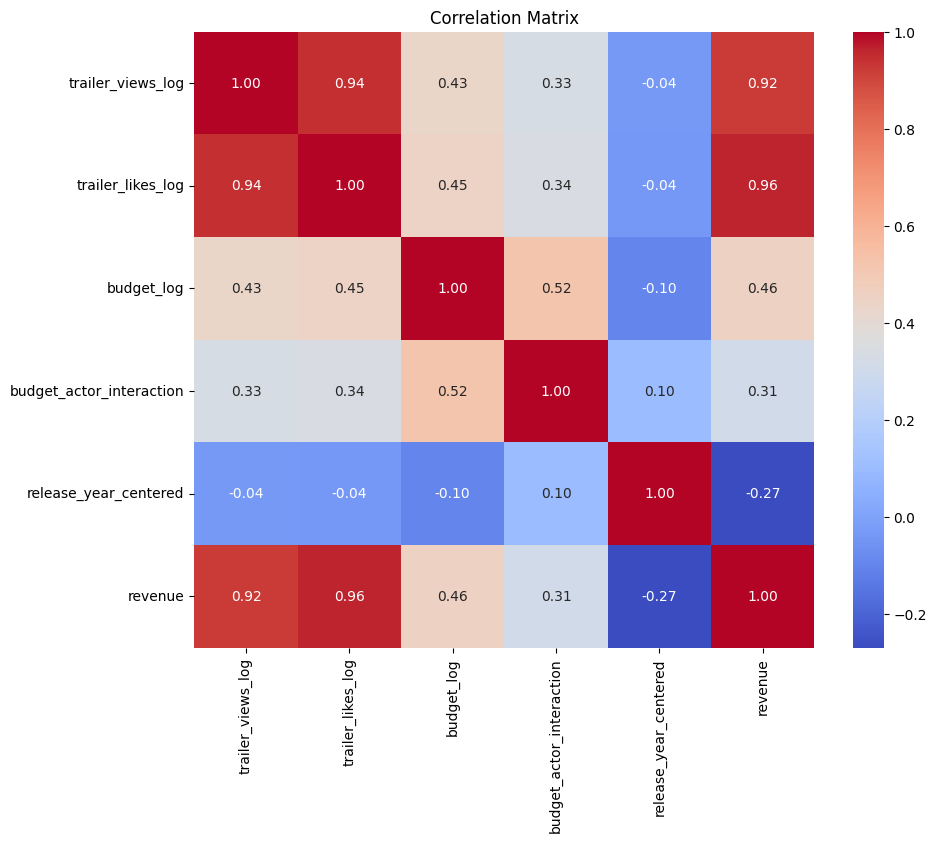

Baseline Model - RMSE: 28.15 Millions, R²: -0.3883


In [3]:
# Calculate correlation matrix
corr_matrix = test.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Prepare data for modeling
X = test.drop('revenue', axis=1)
y = df_sorted_asc['revenue']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
y_train_log = np.log1p(y_train)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create polynomial features for more complex models
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
feature_names = poly.get_feature_names_out(X.columns)

# Scale polynomial features
scaler_poly = StandardScaler()
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
X_test_poly_scaled = scaler_poly.transform(X_test_poly)

# Baseline model (mean prediction)
dummy_pred = np.full_like(y_test, y_train.mean())
RMSE_dummy = np.sqrt(mean_squared_error(y_test, dummy_pred)) / 1e6
R2_dummy = r2_score(y_test, dummy_pred)
print(f"Baseline Model - RMSE: {RMSE_dummy:.2f} Millions, R²: {R2_dummy:.4f}")


# 4. Linear Models

## 4.1 Linear Regression


Cross-validated RMSE: 19.43 Millions
Cross-validated R-squared: 0.79
RMSE: 9.01 Millions
R-squared: 0.86


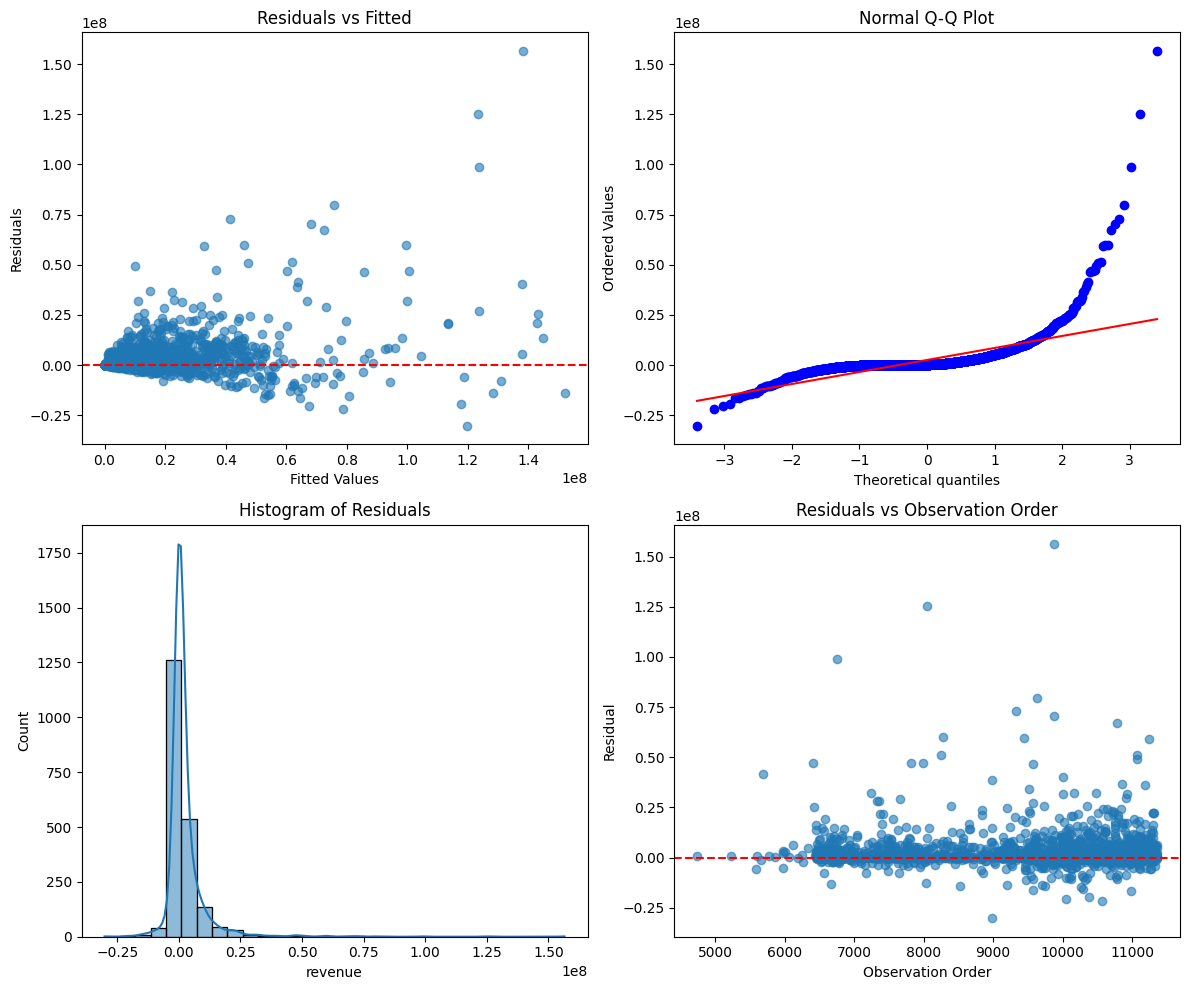

In [4]:
model = LinearRegression()
cv = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_log_cv = cross_val_predict(model, X_train, y_train_log, cv=cv)
y_pred_cv = np.expm1(y_pred_log_cv)
y_true_cv = np.expm1(y_train_log)
rmse_cv = np.sqrt(mean_squared_error(y_true_cv, y_pred_cv)) / 1e6
r2_cv = r2_score(y_true_cv, y_pred_cv)
print(f"Cross-validated RMSE: {round(rmse_cv, 2)} Millions")
print(f"Cross-validated R-squared: {round(r2_cv, 2)}")

model.fit(X_train, y_train_log)
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) / 1e6
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {round(rmse, 2)} Millions")
print(f"R-squared: {round(r2, 2)}")
plot_residual_diagnostics(y_test, y_pred)

# 5. Non-linear Model

## 5.1 Generalized Additive Model (GAM)



RMSE: 8.06 Millions
R-squared: 0.89


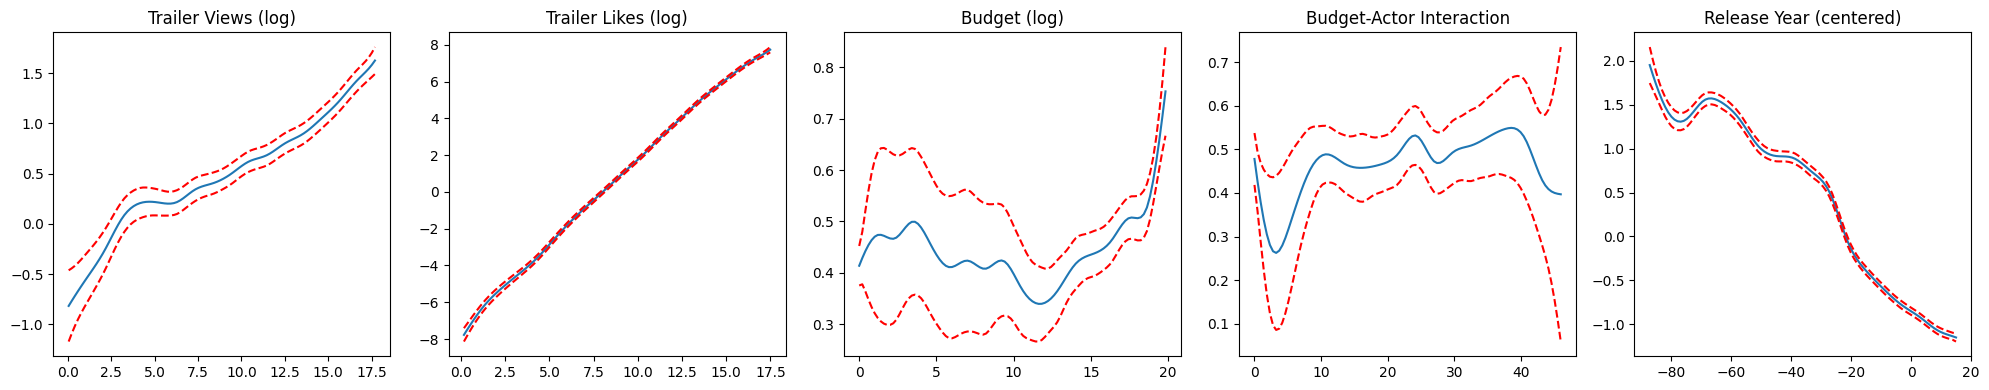

In [5]:
np.int = int
scipy.sparse.csr_matrix.A = property(lambda self: self.toarray())
gam = LinearGAM(s(0) + s(1) + s(2) + s(3) + s(4)).fit(X_train, y_train_log)
y_pred_log = gam.predict(X_test)
y_pred = np.expm1(y_pred_log)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) / 1e6
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {round(rmse, 2)} Millions")
print(f"R-squared: {round(r2, 2)}")

scipy.sparse.csc_matrix.A = property(lambda self: self.toarray())
fig, axs = plt.subplots(1, 5, figsize=(20, 4))
titles = ["Trailer Views (log)", "Trailer Likes (log)", "Budget (log)", "Budget-Actor Interaction", "Release Year (centered)"]
for i, ax in enumerate(axs):
    XX = gam.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX, width=0.95)[1], c='r', ls='--')
    ax.set_title(titles[i])
plt.tight_layout()
plt.show()

## 5.2 Random Forest Regressor


Best RF parameters: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 761}
Random Forest - RMSE: 8.35 Millions, R²: 0.8779


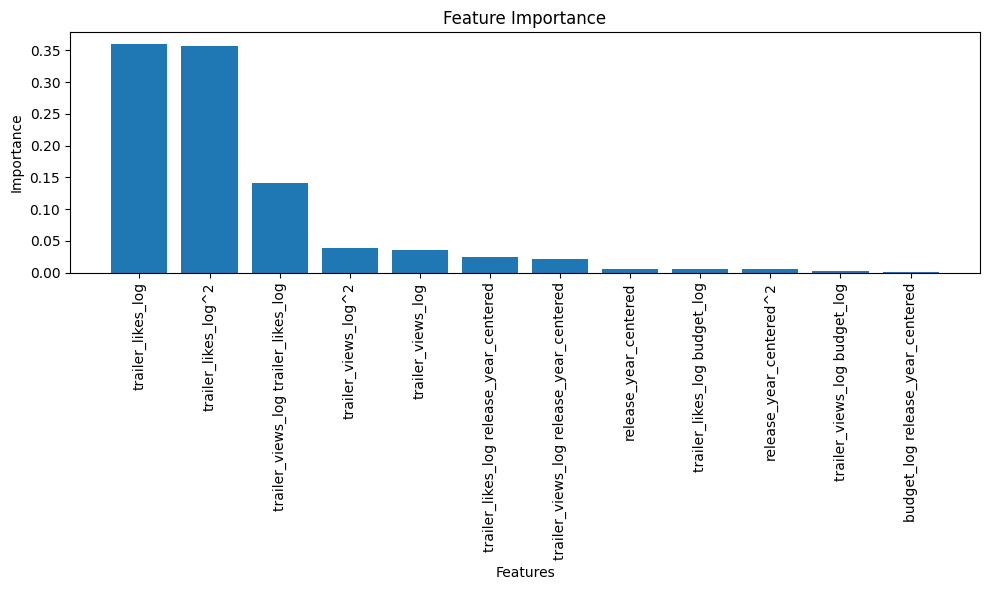

In [6]:
RFR_tune = RandomForestRegressor(random_state=42)
param_dist = {
    'n_estimators': randint(100, 1000),
    'max_depth': [5, 10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5, None]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rand_search = RandomizedSearchCV(RFR_tune, param_distributions=param_dist,
                               n_iter=10, cv=kf, scoring='neg_mean_squared_error',
                               random_state=42, n_jobs=-1)
rand_search.fit(X_train_poly_scaled, y_train_log.values.ravel())
print(f"Best RF parameters: {rand_search.best_params_}")

Best_RFR = rand_search.best_estimator_
y_pred_rf_log = Best_RFR.predict(X_test_poly_scaled)
y_pred_rf = np.expm1(y_pred_rf_log)
RMSE_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf)) / 1e6
R2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest - RMSE: {RMSE_rf:.2f} Millions, R²: {R2_rf:.4f}")

# Feature importance
importances = Best_RFR.feature_importances_
feature_importances = pd.DataFrame(importances, index=feature_names,
                                 columns=["importance"]).sort_values("importance", ascending=False)

# Select important features (importance >= 0.001)
important_features = feature_importances[feature_importances["importance"] >= 0.001].index

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.title("Feature Importance")
important_importance_values = feature_importances.loc[important_features, "importance"]
plt.bar(range(len(important_features)), important_importance_values, align="center")
plt.xticks(range(len(important_features)), important_features, rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# Map feature names to column indices for reduced feature set
important_feature_indices = [i for i, name in enumerate(feature_names) if name in important_features]
X_train_poly_important = X_train_poly_scaled[:, important_feature_indices]
X_test_poly_important = X_test_poly_scaled[:, important_feature_indices]


## 5.4  XGBoost with Time-Based Split


Data shape for time-based split - X: (11362, 50), y: (11362,)
Time-based splitting by release_year...
Train years: [np.int32(1914), np.int32(1915), np.int32(1916), np.int32(1918), np.int32(1919), np.int32(1920), np.int32(1921), np.int32(1922), np.int32(1923), np.int32(1924), np.int32(1925), np.int32(1926), np.int32(1927), np.int32(1928), np.int32(1929), np.int32(1930), np.int32(1931), np.int32(1932), np.int32(1933), np.int32(1934), np.int32(1935), np.int32(1936), np.int32(1937), np.int32(1938), np.int32(1939), np.int32(1940), np.int32(1941), np.int32(1942), np.int32(1943), np.int32(1944), np.int32(1945), np.int32(1946), np.int32(1947), np.int32(1948), np.int32(1949), np.int32(1950), np.int32(1951), np.int32(1952), np.int32(1953), np.int32(1954), np.int32(1955), np.int32(1956), np.int32(1957), np.int32(1958), np.int32(1959), np.int32(1960), np.int32(1961), np.int32(1962), np.int32(1963), np.int32(1964), np.int32(1965), np.int32(1966), np.int32(1967), np.int32(1968), np.int32(1969), np.i

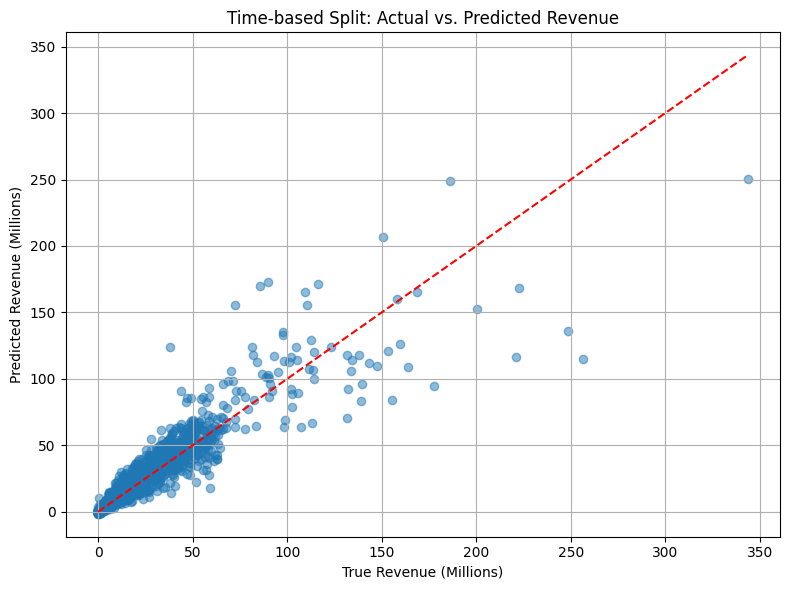

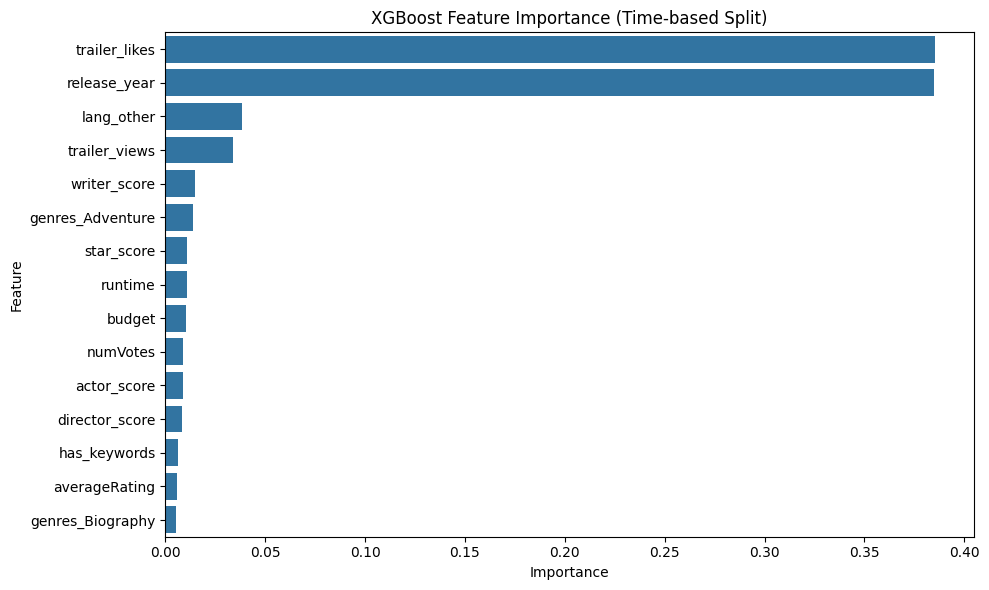

In [7]:
import gc
gc.collect()

# Use the original dataframe for this approach
df_for_time_split = df.copy()

# Ensure we have a release_year column
if "release_date" not in df_for_time_split.columns:
    print("release_date column not found in the original dataset.")
else:
    # Convert to datetime and extract year if not already done
    df_for_time_split["release_date"] = pd.to_datetime(df_for_time_split["release_date"], errors="coerce")
    df_for_time_split["release_year"] = df_for_time_split["release_date"].dt.year

    # Define columns to drop for feature selection
    drop_cols = [
        "Unnamed: 0", "name", "genres", "directors", "writers",
        "actors", "original_language", "production_companies",
        "release_date", "keywords", "revenue"  # we keep 'release_year'!
    ]

    # Create feature matrix and target
    y_time = df_for_time_split["revenue"]
    X_time = df_for_time_split.drop(columns=drop_cols, errors="ignore")

    print(f"Data shape for time-based split - X: {X_time.shape}, y: {y_time.shape}")

    # Perform time-based split
    all_years = sorted(X_time["release_year"].dropna().unique())
    boundary_year = 2015  # Choose a reasonable boundary
    train_years = [year for year in all_years if year < boundary_year]
    test_years = [year for year in all_years if year >= boundary_year]

    print(f"Time-based splitting by release_year...")
    print("Train years:", train_years)
    print("Test years:", test_years)

    # Build masks for splitting
    train_mask = X_time["release_year"].isin(train_years)
    test_mask = X_time["release_year"].isin(test_years)

    # Split data
    X_train_time = X_time[train_mask].copy()
    X_test_time = X_time[test_mask].copy()
    y_train_time = y_time[train_mask]
    y_test_time = y_time[test_mask]

    # Verify split
    overlap = set(X_train_time["release_year"].unique()).intersection(X_test_time["release_year"].unique())
    if overlap:
        print("WARNING: Overlap in train/test years:", overlap)
    else:
        print("No overlap in train/test years (good).")

    print(f"X_train_time shape: {X_train_time.shape}, X_test_time shape: {X_test_time.shape}")

    # Preprocessing - select only numeric columns
    numeric_cols = X_train_time.select_dtypes(include=[np.number]).columns
    X_train_time_numeric = X_train_time[numeric_cols].fillna(0)
    X_test_time_numeric = X_test_time[numeric_cols].fillna(0)

    # Scale the features
    scaler_time = StandardScaler()
    X_train_time_scaled = scaler_time.fit_transform(X_train_time_numeric)
    X_test_time_scaled = scaler_time.transform(X_test_time_numeric)

    # Train the model
    xgb_time = XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1
    )

    xgb_time.fit(X_train_time_scaled, y_train_time)

    # Make predictions
    y_pred_time = xgb_time.predict(X_test_time_scaled)

    # Evaluate
    rmse_time = np.sqrt(mean_squared_error(y_test_time, y_pred_time)) / 1e6
    r2_time = r2_score(y_test_time, y_pred_time)

    print("\n=== PERFORMANCE METRICS (Time-based Split) ===")
    print(f"Test RMSE: {rmse_time:.2f} Millions")
    print(f"Test R²: {r2_time:.4f}")

    # Quick scatter plot
    plt.figure(figsize=(8,6))
    plt.scatter(y_test_time / 1e6, y_pred_time / 1e6, alpha=0.5)
    plt.plot([y_test_time.min() / 1e6, y_test_time.max() / 1e6],
             [y_test_time.min() / 1e6, y_test_time.max() / 1e6], 'r--')
    plt.xlabel("True Revenue (Millions)")
    plt.ylabel("Predicted Revenue (Millions)")
    plt.title("Time-based Split: Actual vs. Predicted Revenue")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot feature importance
    feature_importance = pd.DataFrame({
        'Feature': numeric_cols,
        'Importance': xgb_time.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance.head(15))
    plt.title('XGBoost Feature Importance (Time-based Split)')
    plt.tight_layout()
    plt.show()